In [ ]:
# Cell 1: Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)


In [5]:
# Cell 2: Paths & parameters

data_dir = "/Users/aaki/Downloads/SRH University Documents/Semester 2/Artificial Intellegence/AI Project - Jupyter Notebook/Driver Drowsiness Dataset (DDD)"

img_height = 64
img_width = 64
batch_size = 32


In [6]:
# Cell 3: Create train/validation datasets

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Class names:", class_names)


Found 41793 files belonging to 2 classes.
Using 33435 files for training.
Found 41793 files belonging to 2 classes.
Using 8358 files for validation.
Class names: ['Drowsy', 'Non Drowsy']


2025-12-02 22:19:29.710841: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-12-02 22:19:29.729719: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


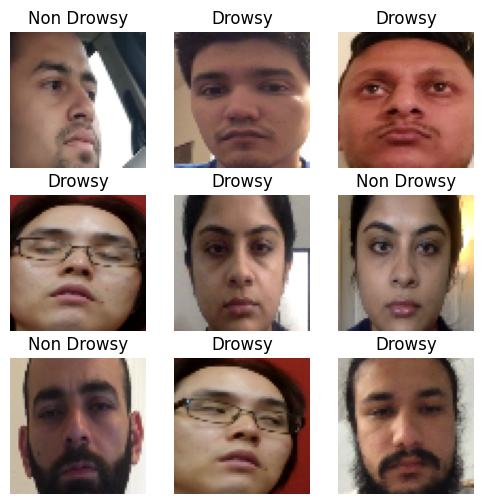

In [7]:
# Cell 4: Cache / prefetch for speed

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Visual inspection
plt.figure(figsize=(6, 6))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")


In [8]:
# Cell 5: Build CNN model

num_classes = len(class_names)

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomContrast(0.1),
    ]
)

inputs = keras.Input(shape=(img_height, img_width, 3))

x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)

# Convolutional layers
x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling2D()(x)

# Dense layers
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation="relu")(x)

# Output layer: binary classification
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)

model.summary()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,081 (4.36 MB)

 Trainable params: 1,142,081 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Cell 6: Compile model

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Training
epochs = 10  # you can increase to 15 if training is fast

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)


Epoch 1/10
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step - accuracy: 0.8914 - loss: 0.2236 - val_accuracy: 0.9974 - val_loss: 0.0115
Epoch 2/10
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 32s 31ms/step - accuracy: 0.9915 - loss: 0.0269 - val_accuracy: 0.9978 - val_loss: 0.0083
Epoch 3/10
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 33s 32ms/step - accuracy: 0.9955 - loss: 0.0156 - val_accuracy: 0.9994 - val_loss: 0.0045
Epoch 4/10
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 33s 32ms/step - accuracy: 0.9949 - loss: 0.0162 - val_accuracy: 0.9998 - val_loss: 0.0013
Epoch 5/10
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 34s 32ms/step - accuracy: 0.9958 - loss: 0.0126 - val_accuracy: 0.9990 - val_loss: 0.0026
Epoch 6/10
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 34s 33ms/step - accuracy: 0.9970 - loss: 0.0086 - val_accuracy: 0.9996 - val_loss: 0.0010
Epoch 7/10
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 35s 33ms/step - accuracy: 0.9961 - loss: 0.0112 - val_accuracy: 0.9987 - val_loss: 0.0032
Epoch 8/10
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 36s 34ms/step - accuracy: 0.9980 -

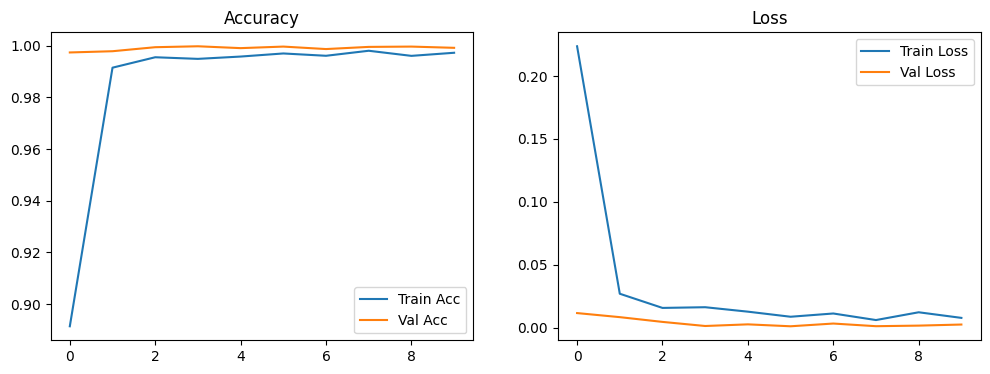

In [10]:
# Cell 7: Plot training history

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Train Acc")
plt.plot(epochs_range, val_acc, label="Val Acc")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()


In [11]:
# Cell 8: Save the model

model.save("drowsiness_cnn.h5")
print("Model saved as drowsiness_cnn.h5")


Model saved as drowsiness_cnn.h5


In [1]:
# Cell 9: Real-time detection setup

import cv2
import numpy as np
from tensorflow import keras

# Load trained model
realtime_model = keras.models.load_model("drowsiness_cnn.h5")

# Class names (same order as training)
class_names = ['Drowsy', 'Non Drowsy']

print("Model loaded successfully!")


NameError: name 'keras' is not defined

In [4]:
# Cell 10: Helper for prediction

def preprocess_eye(eye_img, img_height=64, img_width=64):
    """Preprocess eye image for model prediction."""
    eye_resized = cv2.resize(eye_img, (img_width, img_height))
    eye_rgb = cv2.cvtColor(eye_resized, cv2.COLOR_BGR2RGB)
    eye_array = eye_rgb.astype("float32") / 255.0
    return np.expand_dims(eye_array, axis=0)

def predict_drowsiness(eye_img):
    """Return probability of drowsiness (0 to 1)."""
    x = preprocess_eye(eye_img)
    prob = float(realtime_model.predict(x, verbose=0)[0][0])  # sigmoid output
    return prob


In [13]:
# Cell 11: Webcam detection

# Load Haar cascades
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)
eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)

cap = cv2.VideoCapture(0)

# Drowsiness logic parameters
DROWSY_THRESHOLD = 0.60       # probability above this = drowsy
FRAMES_THRESHOLD = 15         # alarm after these many consecutive drowsy frames
drowsy_frames = 0

print("Starting webcam... Press 'q' to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    display = frame.copy()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # Detect faces
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    is_drowsy_this_frame = False

    for (x, y, w, h) in faces:
        # Draw rectangle around face
        cv2.rectangle(display, (x, y), (x+w, y+h), (255, 255, 0), 2)

        roi_gray = gray[y:y+h, x:x+w]
        roi_color = frame[y:y+h, x:x+w]

        eyes = eye_cascade.detectMultiScale(roi_gray, 1.1, 3)

        for (ex, ey, ew, eh) in eyes:
            eye_img = roi_color[ey:ey+eh, ex:ex+ew]
            prob = predict_drowsiness(eye_img)

            label = f"Drowsy: {prob:.2f}"
            color = (0, 0, 255) if prob >= DROWSY_THRESHOLD else (0, 255, 0)

            # Draw rectangle for eye
            cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), color, 2)
            cv2.putText(roi_color, label, (ex, ey - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
            
            if prob >= DROWSY_THRESHOLD:
                is_drowsy_this_frame = True
        
        break  # use only first face

    # track consecutive drowsy frames
    if is_drowsy_this_frame:
        drowsy_frames += 1
    else:
        drowsy_frames = 0

    # Trigger alarm visually
    if drowsy_frames >= FRAMES_THRESHOLD:
        cv2.putText(display, "WAKE UP! YOU ARE DROWSY!",
                    (50, 80), cv2.FONT_HERSHEY_SIMPLEX, 1.0,
                    (0, 0, 255), 3)

    cv2.imshow("Drowsiness Detection", display)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


Starting webcam... Press 'q' to quit.


NameError: name 'predict_drowsiness' is not defined

In [3]:
# MUST RUN THIS FIRST AFTER EVERY RESTART

import numpy as np
import cv2
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

print("Imports loaded successfully.")


Imports loaded successfully.


In [4]:
realtime_model = keras.models.load_model("drowsiness_cnn.h5")


In [5]:
# Cell 9: Real-time detection setup
import cv2

# Reload the trained model
realtime_model = keras.models.load_model("drowsiness_cnn.h5")

# For binary classification we will assume:
#   0 -> class_names[0]
#   1 -> class_names[1]
print("Class names:", class_names)


NameError: name 'class_names' is not defined